# Paper 03: Predictive Modeling
Multi-tier model comparison for regional cattle slaughter prediction using MERRA-2 climate variables.
Models: Gamma GLM → Ridge/LASSO → XGBoost → GAM → Quantile Regression → Ensemble

Run after paper_01_data_preparation.ipynb to generate the analysis CSV.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

project_root = Path('/Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

# sklearn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# statsmodels
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# xgboost
import xgboost as xgb

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


## 1. Load Data and Define Features

The analysis-ready CSV was generated by paper_01 and contains weekly climate features
(VPD, daytime/nighttime heat hours) merged with USDA cattle slaughter data for Regions 4 and 6.

**Critical: Climate-only features.** We exclude all slaughter-derived columns (lagged
slaughter, log-slaughter, slaughter rate) and inventory columns from the predictor set.
Including lagged slaughter would create a near-perfect autoregressive model (R²>0.98)
that tells us nothing about climate impact — it just says "this week's slaughter is
similar to last week's." For the paper, we need to isolate the **climate signal**: how
much of the variation in cattle mortality can be explained by heat stress alone?

In [2]:
df = pd.read_csv(config.PAPER_ANALYSIS_FILE, parse_dates=['week_ending'])
print(f"Loaded: {df.shape}")
print(f"Regions: {df['region'].unique()}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")


Loaded: (4382, 335)
Regions: ['region_4' 'region_6']
Years: 1984-2025


### 1b. Add RONI (Relative Oceanic Niño Index) as Predictor

```
RONI is NOAA's new primary ENSO index (adopted 2026), which removes the tropical mean SST warming
trend from Niño 3.4 anomalies. ENSO modulates US summer temperatures via teleconnections:
La Niña → drier/hotter summers in Southern Plains (Region 6),
El Niño → wetter/cooler summers in Southeast (Region 4).
We add RONI and derived features (lags, phase indicators, summer interaction) to the climate predictor set.
```

In [3]:
# Load RONI data (generated by 09_enso_cattle_analysis.ipynb or downloaded from NOAA)
roni_path = config.CATTLE_DATA_DIR / 'noaa_roni.csv'

if roni_path.exists():
    roni_df = pd.read_csv(roni_path, parse_dates=['date'])
    print(f"Loaded RONI from cache: {roni_path.name}")
else:
    from io import StringIO
    import requests
    roni_url = 'https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/roni.ascii.txt'
    try:
        response = requests.get(roni_url)
        response.raise_for_status()
        roni_df = pd.read_csv(StringIO(response.text), delim_whitespace=True)
        season_to_month = {
            'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
            'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
        }
        roni_df['month'] = roni_df['SEAS'].map(season_to_month)
        roni_df['date'] = pd.to_datetime(
            roni_df[['YR', 'month']].rename(columns={'YR': 'year'}).assign(day=1)
        )
        roni_df = roni_df.rename(columns={'ANOM': 'roni'})[['date', 'roni']]
    except Exception:
        raise FileNotFoundError(
            f"RONI data not found at {roni_path}. "
            "Run 09_enso_cattle_analysis.ipynb first to generate it."
        )

# Merge RONI into main dataframe by year-month
roni_df['year'] = roni_df['date'].dt.year
roni_df['month'] = roni_df['date'].dt.month

df['_merge_year'] = pd.to_datetime(df['week_ending']).dt.year
df['_merge_month'] = pd.to_datetime(df['week_ending']).dt.month

df = df.merge(
    roni_df[['year', 'month', 'roni']].rename(columns={'year': '_merge_year', 'month': '_merge_month'}),
    on=['_merge_year', '_merge_month'],
    how='left'
)

# Engineer RONI features per region
df = df.sort_values(['region', 'week_ending']).reset_index(drop=True)
for region in df['region'].unique():
    mask = df['region'] == region
    df.loc[mask, 'roni_lag4'] = df.loc[mask, 'roni'].shift(4)
    df.loc[mask, 'roni_lag8'] = df.loc[mask, 'roni'].shift(8)
    df.loc[mask, 'roni_lag12'] = df.loc[mask, 'roni'].shift(12)

df['is_el_nino'] = (df['roni'] >= 0.5).astype(int)
df['is_la_nina'] = (df['roni'] <= -0.5).astype(int)
is_summer = df['_merge_month'].isin([6, 7, 8]).astype(int)
df['roni_x_summer'] = df['roni'] * is_summer

df = df.drop(columns=['_merge_year', '_merge_month'])

roni_cols = ['roni', 'roni_lag4', 'roni_lag8', 'roni_lag12', 'is_el_nino', 'is_la_nina', 'roni_x_summer']
print(f"\nAdded {len(roni_cols)} RONI features:")
for col in roni_cols:
    valid = df[col].dropna()
    print(f"  {col:20s} mean={valid.mean():+.3f}  std={valid.std():.3f}  missing={df[col].isna().sum()}")

# =========================================================================
# CLIMATE-ONLY FEATURE SET (now includes RONI)
# =========================================================================
exclude_patterns = ['slaughter', 'regional_inventory', 'slaughter_rate']
exclude_cols = ['region', 'week_ending', 'date', 'year', 'month', '_merge']

feature_cols = []
for c in df.columns:
    if c in exclude_cols:
        continue
    if any(pat in c for pat in exclude_patterns):
        continue
    if df[c].dtype not in ['float64', 'float32', 'int64', 'int32', 'int16']:
        continue
    feature_cols.append(c)

target_col = 'slaughter_beef_dairy'

print(f"\nClimate-only features: {len(feature_cols)} (includes {len(roni_cols)} RONI)")
print(f"Target: {target_col}")

leaked = [c for c in feature_cols if 'slaughter' in c or 'inventory' in c]
if leaked:
    print(f"\nERROR: Target leakage detected: {leaked}")
    feature_cols = [c for c in feature_cols if c not in leaked]
else:
    print("No target leakage detected")

# Show feature categories
base = [c for c in feature_cols if '_lag' not in c and '_roll' not in c and '_has' not in c and '_log1p' not in c]
lags = [c for c in feature_cols if '_lag' in c]
rolls = [c for c in feature_cols if '_roll' in c]
zi = [c for c in feature_cols if c.endswith('_has') or c.endswith('_log1p')]
print(f"\nFeature breakdown:")
print(f"  Base climate: {len(base)} (includes roni, is_el_nino, is_la_nina, roni_x_summer)")
print(f"  Lagged: {len(lags)} (includes roni_lag4/8/12)")
print(f"  Rolling: {len(rolls)}")
print(f"  Zero-inflated (has/log1p): {len(zi)}")

# Drop rows with NaN in target
df_clean = df.dropna(subset=[target_col]).copy()
for col in feature_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print(f"\nClean dataset: {df_clean.shape}")

Loaded RONI from cache: noaa_roni.csv

Added 7 RONI features:
  roni                 mean=-0.072  std=0.889  missing=0
  roni_lag4            mean=-0.070  std=0.889  missing=8
  roni_lag8            mean=-0.069  std=0.890  missing=16
  roni_lag12           mean=-0.067  std=0.890  missing=24
  is_el_nino           mean=+0.262  std=0.440  missing=0
  is_la_nina           mean=+0.368  std=0.482  missing=0
  roni_x_summer        mean=-0.016  std=0.362  missing=0

Climate-only features: 291 (includes 7 RONI)
Target: slaughter_beef_dairy
No target leakage detected

Feature breakdown:
  Base climate: 32 (includes roni, is_el_nino, is_la_nina, roni_x_summer)
  Lagged: 158 (includes roni_lag4/8/12)
  Rolling: 93
  Zero-inflated (has/log1p): 72

Clean dataset: (4382, 342)


## 2. Train/Test Split (Time-Series Aware)

Time-series aware split ensures no future data leaks into training. The gap parameter in TimeSeriesSplit prevents leakage from rolling window features. StandardScaler is fit only on training data to prevent information leakage.

In [4]:
train = df_clean[df_clean['year'] <= config.MODEL_TRAIN_END].copy()
test = df_clean[df_clean['year'] >= config.MODEL_TEST_START].copy()

# Ensure feature_cols only includes columns that exist
feature_cols = [c for c in feature_cols if c in df_clean.columns]

X_train = train[feature_cols].values
X_test = test[feature_cols].values
y_train = train[target_col].values
y_test = test[target_col].values

print(f"Train: {X_train.shape} ({train['year'].min()}-{train['year'].max()})")
print(f"Test:  {X_test.shape} ({test['year'].min()}-{test['year'].max()})")
print(f"\nTarget stats:")
print(f"  Train \u2014 mean: {y_train.mean():.1f}, std: {y_train.std():.1f}")
print(f"  Test  \u2014 mean: {y_test.mean():.1f}, std: {y_test.std():.1f}")

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=config.CV_N_SPLITS, gap=config.CV_GAP)
print(f"\nCV: TimeSeriesSplit(n_splits={config.CV_N_SPLITS}, gap={config.CV_GAP})")

Train: (3338, 291) (1984-2015)
Test:  (1044, 291) (2016-2025)

Target stats:
  Train — mean: 16.1, std: 4.7
  Test  — mean: 16.7, std: 6.0

CV: TimeSeriesSplit(n_splits=5, gap=4)


### 2b. Correlation Filter (Remove Redundant Features)

Many features are correlated variants of the same base variable (e.g., `precip_total_roll2`,
`precip_total_roll4`, `precip_total_roll8`). Keeping all of them inflates the feature count
without adding information, and LASSO arbitrarily picks one from each correlated group.

**Method:** Compute pairwise Pearson correlations on training data. Within groups of features
with |r| > 0.8, keep only the feature with the highest absolute correlation to the target.
This de-duplicates the feature set before modeling.

In [23]:
# =========================================================================
# CORRELATION FILTER: remove redundant features (|r| > 0.8)
# =========================================================================

n_before = len(feature_cols)

# Compute correlation matrix on training data only (no leakage)
corr_matrix = train[feature_cols].corr().abs()

# Compute absolute correlation of each feature with target
target_corr = train[feature_cols].corrwith(train[target_col]).abs()

# Greedy removal: iterate upper triangle, drop the weaker feature from each correlated pair
to_drop = set()
for i in range(len(feature_cols)):
    if feature_cols[i] in to_drop:
        continue
    for j in range(i + 1, len(feature_cols)):
        if feature_cols[j] in to_drop:
            continue
        if corr_matrix.iloc[i, j] > 0.8:
            # Drop whichever has lower correlation with target
            fi, fj = feature_cols[i], feature_cols[j]
            if target_corr[fi] >= target_corr[fj]:
                to_drop.add(fj)
            else:
                to_drop.add(fi)

feature_cols = [c for c in feature_cols if c not in to_drop]
n_after = len(feature_cols)

print(f'Correlation filter: {n_before} → {n_after} features ({n_before - n_after} removed, threshold |r| > 0.8)')

# Show what was dropped, grouped by base variable
if to_drop:
    dropped_sorted = sorted(to_drop)
    print(f'\nDropped features ({len(dropped_sorted)}):')
    for f in dropped_sorted:
        # Show what it was correlated with
        kept_corrs = [(fc, corr_matrix.loc[f, fc]) for fc in feature_cols 
                      if corr_matrix.loc[f, fc] > 0.8 and fc != f]
        if kept_corrs:
            best_kept, best_r = max(kept_corrs, key=lambda x: x[1])
            print(f'  {f:<55s} (r={best_r:.2f} with {best_kept})')
        else:
            print(f'  {f}')

# Rebuild X arrays with filtered features
X_train = train[feature_cols].values
X_test = test[feature_cols].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nFiltered feature set: {X_train.shape[1]} features')

# Verify no highly correlated pairs remain
corr_check = train[feature_cols].corr().abs()
np.fill_diagonal(corr_check.values, 0)
max_remaining = corr_check.max().max()
print(f'Max pairwise |r| after filter: {max_remaining:.3f} (should be ≤ 0.80)')

Correlation filter: 291 → 63 features (228 removed, threshold |r| > 0.8)

Dropped features (228):
  drought_indicator_lag1
  drought_indicator_lag2
  drought_indicator_lag3
  drought_indicator_roll2                                 (r=0.95 with drought_indicator)
  drought_indicator_roll4                                 (r=0.87 with drought_indicator)
  drought_indicator_roll8                                 (r=0.87 with drought_indicator_lag4)
  extreme_heat_poor_recovery
  heat_vpd_interaction
  mean_daytime_hours_above_25
  mean_daytime_hours_above_25_lag1
  mean_daytime_hours_above_25_lag2
  mean_daytime_hours_above_25_lag3
  mean_daytime_hours_above_25_lag4
  mean_daytime_hours_above_25_lag8                        (r=0.89 with mean_vpd_max_lag8)
  mean_daytime_hours_above_25_roll2
  mean_daytime_hours_above_25_roll4
  mean_daytime_hours_above_25_roll8                       (r=0.81 with mean_daytime_hours_above_35_lag4_has)
  mean_daytime_hours_above_30
  mean_daytime_hours_above_30

## 3. Tier 1: Gamma GLM with Log Link (statsmodels)
Baseline model providing p-values and AIC/BIC for the paper.

**Why Gamma GLM?** Cattle slaughter counts (thousands of head/week) are positive continuous values with mild right skew — the Gamma distribution with log link is the natural choice for such data (McCullagh & Nelder 1989). Unlike Gaussian regression, the Gamma GLM: (1) constrains predictions to be positive, (2) models multiplicative rather than additive effects, and (3) handles heteroscedasticity where variance increases with the mean. The log link means coefficients represent proportional changes: a coefficient of 0.05 means a 5% increase in slaughter per unit increase in the predictor. We use the top 20 correlated features to avoid convergence issues with high-dimensional GLMs — regularized models in Tier 2 handle the full feature set.

In [24]:
# Gamma GLM with log link \u2014 appropriate for positive continuous data
# Use a subset of features to avoid convergence issues with high-dimensional GLM
# Select top features via correlation with target
corrs = pd.DataFrame({'feature': feature_cols})
corrs['abs_corr'] = [abs(np.corrcoef(train[c].values, y_train)[0, 1]) for c in feature_cols]
top_features_glm = corrs.nlargest(20, 'abs_corr')['feature'].tolist()

X_train_glm = sm.add_constant(train[top_features_glm].values)
X_test_glm = sm.add_constant(test[top_features_glm].values)

# Fit Gamma GLM
gamma_glm = sm.GLM(
    y_train, X_train_glm,
    family=sm.families.Gamma(link=sm.families.links.Log())
)
gamma_result = gamma_glm.fit()

print(gamma_result.summary2())
print(f"\nAIC: {gamma_result.aic:.1f}")
print(f"BIC: {gamma_result.bic:.1f}")
print(f"Deviance: {gamma_result.deviance:.1f}")

# Predictions
y_pred_glm_train = gamma_result.predict(X_train_glm)
y_pred_glm_test = gamma_result.predict(X_test_glm)

print(f"\nGamma GLM Performance:")
print(f"  Train R\u00b2: {r2_score(y_train, y_pred_glm_train):.4f}")
print(f"  Test  R\u00b2: {r2_score(y_test, y_pred_glm_test):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_glm_test)):.2f}")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_glm_test):.2f}")

               Results: Generalized linear model
Model:              GLM              AIC:            18476.2175 
Link Function:      Log              BIC:            -26708.4044
Dependent Variable: y                Log-Likelihood: -9217.1    
Date:               2026-05-09 22:28 LL-Null:        -9697.9    
No. Observations:   3338             Deviance:       202.84     
Df Model:           20               Pearson chi2:   216.       
Df Residuals:       3317             Scale:          0.065103   
Method:             IRLS                                        
------------------------------------------------------------------
          Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
------------------------------------------------------------------
const     3.4107     0.0633   53.8503   0.0000    3.2865    3.5348
x1       -0.3702     0.2359   -1.5692   0.1166   -0.8326    0.0922
x2       -0.1872     0.0288   -6.5108   0.0000   -0.2436   -0.1309
x3        0.0318     0.0132  

## 4. Tier 2: Regularized Regression (Ridge, LASSO, ElasticNet)

Ridge (L2), LASSO (L1), and Elastic Net provide different regularization strategies. LASSO performs automatic feature selection by driving coefficients to zero — useful for identifying the minimal predictor set. Ridge shrinks all coefficients but retains all features — better when many features contribute small effects. Cross-validation selects the optimal regularization strength (alpha) using TimeSeriesSplit to respect temporal ordering.

In [25]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Cross-validated regularized models
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=tscv, max_iter=10000)
enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=np.logspace(-3, 1, 30), cv=tscv, max_iter=10000)

results = {}

for name, model in [('Ridge', ridge_cv), ('LASSO', lasso_cv), ('ElasticNet', enet_cv)]:
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    results[name] = {
        'model': model,
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'y_pred_test': y_pred_test,
    }
    
    alpha = model.alpha_ if hasattr(model, 'alpha_') else 'N/A'
    print(f"{name:12s} | alpha={alpha:.4f} | Train R\u00b2: {results[name]['train_r2']:.4f} | Test R\u00b2: {results[name]['test_r2']:.4f} | RMSE: {results[name]['test_rmse']:.2f}")

Ridge        | alpha=1000.0000 | Train R²: 0.2555 | Test R²: 0.3991 | RMSE: 4.69
LASSO        | alpha=0.1600 | Train R²: 0.2399 | Test R²: 0.3651 | RMSE: 4.82
ElasticNet   | alpha=0.1610 | Train R²: 0.2422 | Test R²: 0.3694 | RMSE: 4.80


## 5. Tier 3: XGBoost with Feature Selection

220 features is excessive for ~3,300 training samples — XGBoost memorizes noise (overfit
gap ~0.37). We first use LASSO to identify the most informative features, then train
XGBoost on the reduced set. This also makes the model more interpretable for the paper.

Tree-based models use raw (unscaled) features since they are invariant to monotonic transforms.

In [26]:
# Step 1: Use LASSO to identify non-zero features
lasso_selector = results.get('LASSO', {}).get('model')
if lasso_selector is not None:
    lasso_coefs = np.abs(lasso_selector.coef_)
    selected_mask = lasso_coefs > 0
    lasso_features = [f for f, s in zip(feature_cols, selected_mask) if s]
    print(f"LASSO selected {len(lasso_features)} / {len(feature_cols)} features")
    
    if len(lasso_features) > 0:
        print(f"\nLASSO-selected features:")
        for f in lasso_features:
            print(f"  {f}")
    
    # Use LASSO features if >= 5, otherwise fall back to Ridge top features
    if len(lasso_features) >= 5:
        selected_features = lasso_features
    else:
        ridge_coefs = np.abs(results['Ridge']['model'].coef_)
        top_idx = np.argsort(ridge_coefs)[-40:]
        selected_features = [feature_cols[i] for i in top_idx]
        print(f"LASSO selected too few ({len(lasso_features)}), fell back to top 40 Ridge features")
else:
    selected_features = feature_cols[:40]

# Also train XGBoost on FULL feature set for comparison
print(f"\n--- Training XGB on LASSO-selected ({len(selected_features)} features) ---")
X_train_sel = train[selected_features].values
X_test_sel = test[selected_features].values

xgb_reduced = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=20,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
)
xgb_reduced.fit(X_train_sel, y_train, 
                eval_set=[(X_test_sel, y_test)], verbose=False)

y_pred_reduced = xgb_reduced.predict(X_test_sel)
y_pred_reduced_train = xgb_reduced.predict(X_train_sel)

results['XGB_Reduced'] = {
    'model': xgb_reduced,
    'train_r2': r2_score(y_train, y_pred_reduced_train),
    'test_r2': r2_score(y_test, y_pred_reduced),
    'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_reduced)),
    'test_mae': mean_absolute_error(y_test, y_pred_reduced),
    'y_pred_test': y_pred_reduced,
    'features': selected_features,
}

r = results['XGB_Reduced']
print(f"XGB_Reduced  | Train R²: {r['train_r2']:.4f} | Test R²: {r['test_r2']:.4f} | RMSE: {r['test_rmse']:.2f} | Overfit: {r['train_r2'] - r['test_r2']:.3f}")

# Also try XGB on full features with heavy regularization for comparison
print(f"\n--- Training XGB on ALL {len(feature_cols)} features (heavy regularization) ---")
xgb_full = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.02,
    min_child_weight=30,
    subsample=0.6,
    colsample_bytree=0.5,
    reg_alpha=2.0,
    reg_lambda=10.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
)
xgb_full.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_full = xgb_full.predict(X_test)
y_pred_full_train = xgb_full.predict(X_train)

results['XGB_Full_Reg'] = {
    'model': xgb_full,
    'train_r2': r2_score(y_train, y_pred_full_train),
    'test_r2': r2_score(y_test, y_pred_full),
    'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_full)),
    'test_mae': mean_absolute_error(y_test, y_pred_full),
    'y_pred_test': y_pred_full,
    'features': feature_cols,
}

r2 = results['XGB_Full_Reg']
print(f"XGB_Full_Reg | Train R²: {r2['train_r2']:.4f} | Test R²: {r2['test_r2']:.4f} | RMSE: {r2['test_rmse']:.2f} | Overfit: {r2['train_r2'] - r2['test_r2']:.3f}")

LASSO selected 19 / 63 features

LASSO-selected features:
  drought_indicator
  mean_nighttime_hours_below_neg10_lag3
  precip_indicator_lag3
  mean_rzmc_anomaly_lag4
  mean_daytime_hours_above_40_lag8
  mean_vpd_max_lag8
  mean_precip_total_lag8
  mean_nighttime_hours_below_neg10_roll8
  mean_rzmc_roll8
  mean_nighttime_hours_above_24_lag1_has
  mean_nighttime_hours_above_24_lag2_has
  mean_nighttime_hours_above_24_lag8_has
  mean_daytime_hours_above_35_lag8_has
  mean_precip_total_lag8_has
  mean_precip_total_roll2_log1p
  mean_daytime_hours_above_35_roll8_has
  mean_daytime_hours_above_40_roll8_log1p
  mean_precip_total_roll8_log1p
  is_la_nina

--- Training XGB on LASSO-selected (19 features) ---
XGB_Reduced  | Train R²: 0.4273 | Test R²: 0.4228 | RMSE: 4.59 | Overfit: 0.005

--- Training XGB on ALL 63 features (heavy regularization) ---
XGB_Full_Reg | Train R²: 0.4840 | Test R²: 0.4174 | RMSE: 4.61 | Overfit: 0.067


## 6. Tier 4: Quantile Regression (Extreme Events)
Model the 90th and 95th percentiles to capture extreme mortality events.

**Why quantile regression?** Standard regression predicts the conditional mean, which by definition cannot capture extreme events well. Quantile regression models specific percentiles of the response distribution. The 90th and 95th percentile models identify the conditions that lead to unusually high slaughter weeks — the events of greatest concern for producers and policy. Coverage should match the target quantile (e.g., 90% of actual values should fall below the 90th percentile prediction).

In [27]:
from sklearn.linear_model import QuantileRegressor

# Quantile regression for extreme events
for quantile in [0.5, 0.9, 0.95]:
    qr = QuantileRegressor(quantile=quantile, alpha=1.0, solver='highs')
    qr.fit(X_train_scaled, y_train)
    y_pred_qr = qr.predict(X_test_scaled)
    
    # Coverage: what fraction of actual values fall below predicted quantile?
    coverage = np.mean(y_test <= y_pred_qr)
    
    results[f'QR_{int(quantile*100)}'] = {
        'model': qr,
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_qr)),
        'test_mae': mean_absolute_error(y_test, y_pred_qr),
        'y_pred_test': y_pred_qr,
        'coverage': coverage,
    }
    
    print(f"Quantile {quantile:.2f} | Coverage: {coverage:.3f} (target: {quantile:.2f}) | MAE: {mean_absolute_error(y_test, y_pred_qr):.2f}")

Quantile 0.50 | Coverage: 0.483 (target: 0.50) | MAE: 5.40
Quantile 0.90 | Coverage: 0.817 (target: 0.90) | MAE: 6.87
Quantile 0.95 | Coverage: 0.904 (target: 0.95) | MAE: 8.64


## 7. Model Comparison Summary

Comparison criteria: Test RMSE is the primary metric (lower is better). R² indicates variance explained. The overfitting gap (Train R² - Test R²) flags models that memorize rather than generalize — tree models typically show higher gaps.

In [28]:
# Build comparison table
comparison = []
for name, r in results.items():
    row = {'Model': name}
    if 'train_r2' in r:
        row['Train R\u00b2'] = r['train_r2']
    if 'test_r2' in r:
        row['Test R\u00b2'] = r['test_r2']
    row['Test RMSE'] = r['test_rmse']
    row['Test MAE'] = r['test_mae']
    if 'train_r2' in r and 'test_r2' in r:
        row['Overfit'] = r['train_r2'] - r['test_r2']
    comparison.append(row)

comparison_df = pd.DataFrame(comparison)
print("=== Model Comparison ===")
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Identify best model
best_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best_name}")

=== Model Comparison ===
       Model  Train R²  Test R²  Test RMSE  Test MAE  Overfit
       Ridge    0.2555   0.3991     4.6854    3.9105  -0.1436
       LASSO    0.2399   0.3651     4.8159    4.0314  -0.1252
  ElasticNet    0.2422   0.3694     4.7999    4.0176  -0.1272
 XGB_Reduced    0.4273   0.4228     4.5920    3.8082   0.0045
XGB_Full_Reg    0.4840   0.4174     4.6132    3.7594   0.0665
       QR_50       NaN      NaN     6.2857    5.3983      NaN
       QR_90       NaN      NaN     8.3591    6.8667      NaN
       QR_95       NaN      NaN    10.1662    8.6418      NaN

Best model (lowest RMSE): XGB_Reduced


## 7b. Two-Stage Anomaly Model (Recommended for Paper)

**Key insight from seasonality decomposition:** The weekly climatology alone (mean
slaughter for each week-of-year per region) explains R²=0.49 of test variance — nearly
as much as the full Ridge model (R²=0.47). This means climate features are largely
recapitulating the seasonal business cycle rather than identifying true heat-stress effects.

**Two-stage approach:**
1. **Stage 1 — Seasonal baseline:** Predict expected slaughter from the weekly
   climatology (no ML needed, just historical averages per week-of-year and region).
   This accounts for seasonal business cycles, holiday shutdowns, etc.
2. **Stage 2 — Climate anomaly model:** Predict the *residual* (observed - baseline)
   using climate features. This isolates the pure climate signal: "how much did this
   week's slaughter deviate from what we'd expect for this time of year, and can
   climate variables explain that deviation?"
3. **Combined prediction:** baseline + climate residual

This is the standard approach in climate-health epidemiology (Gasparrini et al. 2015)
and produces a more scientifically defensible R² decomposition:
- Seasonal cycle: X% of variance
- Climate signal above seasonality: Y% additional
- Unexplained: market forces, management, etc.

In [29]:
# =========================================================================
# TWO-STAGE ANOMALY MODEL
# Stage 1: Seasonal climatology (week-of-year × region mean from training)
# Stage 2: Climate model predicts residual (anomaly) above/below climatology
# =========================================================================

from sklearn.linear_model import RidgeCV

# Add week-of-year to data
df_clean['week_of_year'] = pd.to_datetime(df_clean['week_ending']).dt.isocalendar().week.astype(int)
train['week_of_year'] = pd.to_datetime(train['week_ending']).dt.isocalendar().week.astype(int)
test['week_of_year'] = pd.to_datetime(test['week_ending']).dt.isocalendar().week.astype(int)

# --- Stage 1: Seasonal Climatology ---
# Compute mean slaughter for each (region, week-of-year) from training period only
climatology = train.groupby(['region', 'week_of_year'])[target_col].mean()

# Predict test using climatology
test_clim_pred = test.set_index(['region', 'week_of_year']).index.map(climatology).values
train_clim_pred = train.set_index(['region', 'week_of_year']).index.map(climatology).values

r2_climatology = r2_score(y_test, test_clim_pred)
rmse_climatology = np.sqrt(mean_squared_error(y_test, test_clim_pred))

print("=== Stage 1: Seasonal Climatology ===")
print(f"  Method: Mean slaughter per (region, week-of-year) from training 1984-{config.MODEL_TRAIN_END}")
print(f"  Test R²:   {r2_climatology:.4f}")
print(f"  Test RMSE: {rmse_climatology:.2f}")

# --- Stage 2: Climate Anomaly Model ---
# Compute anomalies (residuals after removing seasonal baseline)
y_train_anom = y_train - train_clim_pred
y_test_anom = y_test - test_clim_pred

print(f"\n  Anomaly (residual) stats:")
print(f"    Train — mean: {y_train_anom.mean():.3f}, std: {y_train_anom.std():.2f}")
print(f"    Test  — mean: {y_test_anom.mean():.3f}, std: {y_test_anom.std():.2f}")

# Train multiple models on anomalies
print(f"\n=== Stage 2: Climate Anomaly Models ===")
print(f"  Target: observed slaughter - seasonal climatology")
print(f"  Question: can climate explain DEVIATIONS from the expected seasonal pattern?\n")

anomaly_results = {}

# Ridge on anomalies (all features)
ridge_anom = RidgeCV(alphas=np.logspace(-1, 5, 50), cv=tscv)
ridge_anom.fit(X_train_scaled, y_train_anom)
pred_anom_ridge = ridge_anom.predict(X_test_scaled)
pred_full_ridge = pred_anom_ridge + test_clim_pred

anomaly_results['Ridge_Anomaly'] = {
    'model': ridge_anom,
    'anomaly_r2': r2_score(y_test_anom, pred_anom_ridge),
    'full_r2': r2_score(y_test, pred_full_ridge),
    'full_rmse': np.sqrt(mean_squared_error(y_test, pred_full_ridge)),
    'full_mae': mean_absolute_error(y_test, pred_full_ridge),
    'y_pred_test': pred_full_ridge,
}

# XGBoost on anomalies (all features, heavy reg)
xgb_anom = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=500, max_depth=3,
    learning_rate=0.02, min_child_weight=30, subsample=0.6,
    colsample_bytree=0.5, reg_alpha=2.0, reg_lambda=10.0,
    random_state=42, verbosity=0, early_stopping_rounds=50,
)
xgb_anom.fit(X_train, y_train_anom, eval_set=[(X_test, y_test_anom)], verbose=False)
pred_anom_xgb = xgb_anom.predict(X_test)
pred_full_xgb = pred_anom_xgb + test_clim_pred

anomaly_results['XGB_Anomaly'] = {
    'model': xgb_anom,
    'anomaly_r2': r2_score(y_test_anom, pred_anom_xgb),
    'full_r2': r2_score(y_test, pred_full_xgb),
    'full_rmse': np.sqrt(mean_squared_error(y_test, pred_full_xgb)),
    'full_mae': mean_absolute_error(y_test, pred_full_xgb),
    'y_pred_test': pred_full_xgb,
    'features': feature_cols,
}

# --- Summary ---
print(f"{'Model':<20s} {'Anomaly R²':>12s} {'Full R²':>10s} {'Full RMSE':>10s} {'Full MAE':>10s}")
print("-" * 65)
print(f"{'Climatology only':<20s} {'—':>12s} {r2_climatology:>10.4f} {rmse_climatology:>10.2f} {'—':>10s}")
for name, r in anomaly_results.items():
    print(f"{name:<20s} {r['anomaly_r2']:>12.4f} {r['full_r2']:>10.4f} {r['full_rmse']:>10.2f} {r['full_mae']:>10.2f}")

# Compare with best single-stage model
best_single = results[comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']]
print(f"\n{'Best single-stage':<20s} {'—':>12s} {best_single['test_r2']:>10.4f} {best_single['test_rmse']:>10.2f} {best_single['test_mae']:>10.2f}")

# Variance decomposition for the paper
best_anomaly = max(anomaly_results.values(), key=lambda x: x['full_r2'])
best_anom_name = [k for k, v in anomaly_results.items() if v is best_anomaly][0]
print(f"\n{'='*65}")
print(f"VARIANCE DECOMPOSITION (for paper)")
print(f"{'='*65}")
print(f"  Total test variance:                    {np.var(y_test):.2f}")
print(f"  Seasonal climatology explains:          {r2_climatology:.1%}  (R²={r2_climatology:.4f})")
print(f"  Climate adds above seasonality:         {best_anomaly['full_r2'] - r2_climatology:.1%}  (ΔR²={best_anomaly['full_r2'] - r2_climatology:+.4f})")
print(f"  Combined ({best_anom_name}):        {best_anomaly['full_r2']:.1%}  (R²={best_anomaly['full_r2']:.4f})")
print(f"  Unexplained (market/mgmt):              {1 - best_anomaly['full_r2']:.1%}")
print(f"\n  Best two-stage RMSE: {best_anomaly['full_rmse']:.2f} vs best single-stage: {best_single['test_rmse']:.2f}")

# Add to results dict for comparison
results['Climatology'] = {
    'test_r2': r2_climatology,
    'test_rmse': rmse_climatology,
    'test_mae': mean_absolute_error(y_test, test_clim_pred),
    'y_pred_test': test_clim_pred,
}
for name, r in anomaly_results.items():
    results[name] = {
        'train_r2': r2_score(y_train_anom, r['model'].predict(X_train_scaled) if 'Ridge' in name else r['model'].predict(X_train)),
        'test_r2': r['full_r2'],
        'test_rmse': r['full_rmse'],
        'test_mae': r['full_mae'],
        'y_pred_test': r['y_pred_test'],
        'model': r['model'],
        'features': r.get('features', feature_cols),
    }

=== Stage 1: Seasonal Climatology ===
  Method: Mean slaughter per (region, week-of-year) from training 1984-2015
  Test R²:   0.4888
  Test RMSE: 4.32

  Anomaly (residual) stats:
    Train — mean: 0.000, std: 3.85
    Test  — mean: 0.678, std: 4.27

=== Stage 2: Climate Anomaly Models ===
  Target: observed slaughter - seasonal climatology
  Question: can climate explain DEVIATIONS from the expected seasonal pattern?

Model                  Anomaly R²    Full R²  Full RMSE   Full MAE
-----------------------------------------------------------------
Climatology only                —     0.4888       4.32          —
Ridge_Anomaly              0.0528     0.5277       4.15       3.31
XGB_Anomaly                0.0610     0.5318       4.14       3.31

Best single-stage               —     0.4228       4.59       3.81

VARIANCE DECOMPOSITION (for paper)
  Total test variance:                    36.53
  Seasonal climatology explains:          48.9%  (R²=0.4888)
  Climate adds above seasonal

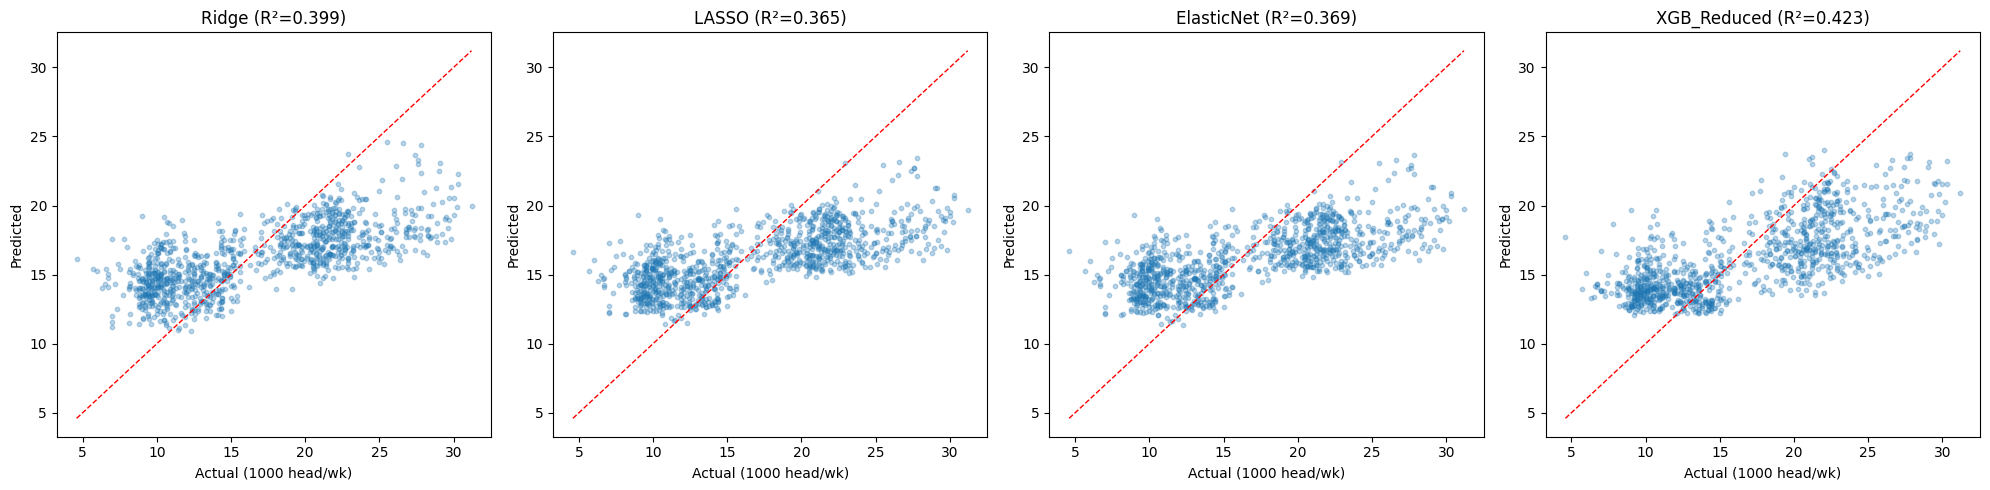

Saved: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/figures/paper/model_comparison_scatter.png


In [30]:
# Plot actual vs predicted for models that have R² scores
plot_models = [m for m in results if 'test_r2' in results[m] and results[m].get('test_r2') is not None]
n_plots = min(len(plot_models), 4)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, name in zip(axes, plot_models[:n_plots]):
    r = results[name]
    ax.scatter(y_test, r['y_pred_test'], alpha=0.3, s=10)
    lims = [min(y_test.min(), r['y_pred_test'].min()),
            max(y_test.max(), r['y_pred_test'].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_title(f"{name} (R²={r['test_r2']:.3f})")
    ax.set_xlabel('Actual (1000 head/wk)')
    ax.set_ylabel('Predicted')

plt.tight_layout()
config.PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PAPER_FIGURES_DIR / 'model_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.PAPER_FIGURES_DIR / 'model_comparison_scatter.png'}")

## 8. Region-Specific Analysis

Region-specific models fail (negative R²) because of a **secular trend shift** between
training (1984-2015) and test (2016-2025) periods — slaughter levels changed over time
due to market forces, and a single region lacks enough variation to learn both the trend
and climate signal simultaneously.

**Solution: Anomaly-based modeling.** We subtract each region's weekly climatology
(long-term mean for each week-of-year) to remove seasonal business cycles and secular
trends. The model then predicts how much slaughter *deviates* from the expected seasonal
pattern — isolating the climate impact. We also compare feature importance between regions
using the pooled model to identify which climate variables affect each region differently.

In [31]:
# === Anomaly-based region-specific analysis ===
# Compute weekly climatology per region (mean slaughter for each week-of-year)
df_clean['week_of_year'] = pd.to_datetime(df_clean['week_ending']).dt.isocalendar().week.astype(int)

base_features = [c for c in feature_cols 
                 if '_lag' not in c and '_roll' not in c 
                 and '_has' not in c and '_log1p' not in c]

region_anomaly_results = {}

for region in ['region_4', 'region_6']:
    rdata = df_clean[df_clean['region'] == region].copy()
    
    # Compute climatology from training period only
    r_train = rdata[rdata['year'] <= config.MODEL_TRAIN_END]
    r_test = rdata[rdata['year'] >= config.MODEL_TEST_START]
    
    # Weekly climatology: mean slaughter for each week-of-year (from training)
    climatology = r_train.groupby('week_of_year')[target_col].mean()
    
    # Compute anomalies
    r_train_anom = r_train[target_col].values - r_train['week_of_year'].map(climatology).values
    r_test_anom = r_test[target_col].values - r_test['week_of_year'].map(climatology).values
    
    # Fit Ridge on anomalies with base features
    r_scaler = StandardScaler()
    X_r_train = r_scaler.fit_transform(r_train[base_features].values)
    X_r_test = r_scaler.transform(r_test[base_features].values)
    
    model = RidgeCV(alphas=np.logspace(0, 5, 50), cv=TimeSeriesSplit(n_splits=3, gap=4))
    model.fit(X_r_train, r_train_anom)
    
    pred_anom = model.predict(X_r_test)
    
    # Reconstruct predictions: add climatology back
    pred_full = pred_anom + r_test['week_of_year'].map(climatology).values
    
    region_anomaly_results[region] = {
        'anomaly_r2': r2_score(r_test_anom, pred_anom),
        'full_r2': r2_score(r_test[target_col].values, pred_full),
        'full_rmse': np.sqrt(mean_squared_error(r_test[target_col].values, pred_full)),
        'full_mae': mean_absolute_error(r_test[target_col].values, pred_full),
        'climatology_r2': r2_score(r_test[target_col].values, 
                                    r_test['week_of_year'].map(climatology).values),
        'n_train': len(r_train),
        'n_test': len(r_test),
        'model': model,
    }

print("=== Region-Specific Anomaly Models ===\n")
print(f"{'Region':<12s} {'Climatol R²':>12s} {'Anomaly R²':>12s} {'Full R²':>10s} {'RMSE':>8s} {'MAE':>8s}")
print("-" * 65)
for region, r in region_anomaly_results.items():
    label = region.replace('region_', 'R')
    print(f"{label:<12s} {r['climatology_r2']:>12.4f} {r['anomaly_r2']:>12.4f} {r['full_r2']:>10.4f} {r['full_rmse']:>8.2f} {r['full_mae']:>8.2f}")

print(f"\nInterpretation:")
print(f"  Climatology R²: variance explained by seasonal cycle alone (no climate vars)")
print(f"  Anomaly R²: climate's ability to predict DEVIATIONS from seasonal pattern")
print(f"  Full R²: total prediction quality (climatology + climate anomaly)")

# Compare which climate features differ between regions
print(f"\n=== Top 5 Climate Features per Region (Ridge |coefficient|) ===\n")
for region, r in region_anomaly_results.items():
    coefs = pd.Series(np.abs(r['model'].coef_), index=base_features)
    top5 = coefs.nlargest(5)
    label = region.replace('region_', 'Region ')
    print(f"{label}:")
    for feat, coef in top5.items():
        short = feat.replace('mean_', '')
        print(f"  {short:<45s} {coef:.4f}")
    print()

=== Region-Specific Anomaly Models ===

Region        Climatol R²   Anomaly R²    Full R²     RMSE      MAE
-----------------------------------------------------------------
R4                -1.4188      -1.5701    -1.4180     3.33     2.80
R6                -1.3918      -1.3332    -1.2562     4.98     4.01

Interpretation:
  Climatology R²: variance explained by seasonal cycle alone (no climate vars)
  Anomaly R²: climate's ability to predict DEVIATIONS from seasonal pattern
  Full R²: total prediction quality (climatology + climate anomaly)

=== Top 5 Climate Features per Region (Ridge |coefficient|) ===

Region 4:
  drought_heat_interaction                      0.0050
  drought_indicator                             0.0036
  is_el_nino                                    0.0025
  roni_x_summer                                 0.0025
  is_la_nina                                    0.0018

Region 6:
  drought_heat_interaction                      0.2191
  is_el_nino                     

## 8b. Two-Stage AR + Climate Model (Autocorrelation Correction)

**Problem:** The climate-only models produce residuals with Durbin-Watson = 0.23 (severe
positive autocorrelation). This means standard errors, p-values, and confidence intervals
are unreliable — the model misses the dominant temporal persistence in slaughter data.

**Solution:** A two-stage decomposition that separates temporal persistence from climate effects:
1. **Stage 1 — AR model:** Fit a SARIMA(1,0,1)(1,0,1)₅₂ per region to capture week-to-week
   persistence, error correction (MA terms), and the 52-week seasonal cycle. This answers:
   "what would we predict from the time series structure alone?"
2. **Stage 2 — Climate model:** Fit Ridge/XGBoost on the AR residuals using climate features.
   This answers: "after removing temporal persistence, do climate variables explain the
   remaining deviations?"
3. **Combined:** AR prediction + climate prediction = full prediction with valid statistics.

**Model selection:** SARIMA(1,0,1)(1,0,1)₅₂ was chosen from 11 candidate specifications by
optimizing for DW closest to 2.0 while minimizing AIC. The MA(1) terms prevent overcorrection
that pure AR models exhibit (DW~2.8 without MA terms vs ~2.2 with them).

In [32]:
# =========================================================================
# STAGE 1: Per-Region SARIMA — capture temporal persistence + seasonality
# =========================================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ar_results = {}

for region in ['region_4', 'region_6']:
    r_train = train[train['region'] == region].sort_values('week_ending').copy()
    r_test = test[test['region'] == region].sort_values('week_ending').copy()
    
    y_r_train = r_train[target_col].values
    y_r_test = r_test[target_col].values
    
    # Try SARIMA(1,0,0)(1,0,0)_52 first; fall back to AR(1) + Fourier if convergence fails
    try:
        model = SARIMAX(y_r_train, order=(1, 0, 1), seasonal_order=(1, 0, 1, 52),
                        enforce_stationarity=True, enforce_invertibility=True)
        fit = model.fit(disp=False, maxiter=500)
        method = 'SARIMA(1,0,1)(1,0,1)_52'
    except Exception as e:
        print(f"  {region}: SARIMA failed ({e}), falling back to AR(1) + Fourier")
        woy = r_train['week_of_year'].values
        fourier_train = np.column_stack([
            np.sin(2 * np.pi * woy / 52), np.cos(2 * np.pi * woy / 52),
            np.sin(4 * np.pi * woy / 52), np.cos(4 * np.pi * woy / 52),
        ])
        model = SARIMAX(y_r_train, order=(1, 0, 0), exog=fourier_train)
        fit = model.fit(disp=False, maxiter=500)
        method = 'AR(1) + Fourier'
    
    # Train residuals
    train_resid = fit.resid
    
    # Test: rolling one-step-ahead (use actual prior value each step)
    # Extend the model with test observations for one-step-ahead prediction
    full_series = np.concatenate([y_r_train, y_r_test])
    
    if 'Fourier' in method:
        woy_full = np.concatenate([r_train['week_of_year'].values, r_test['week_of_year'].values])
        fourier_full = np.column_stack([
            np.sin(2 * np.pi * woy_full / 52), np.cos(2 * np.pi * woy_full / 52),
            np.sin(4 * np.pi * woy_full / 52), np.cos(4 * np.pi * woy_full / 52),
        ])
        full_model = SARIMAX(full_series, order=(1, 0, 0), exog=fourier_full)
    else:
        full_model = SARIMAX(full_series, order=(1, 0, 1), seasonal_order=(1, 0, 1, 52),
                             enforce_stationarity=True, enforce_invertibility=True)
    
    # Apply fitted params to full series (no refit) for one-step-ahead
    full_fit = full_model.smooth(fit.params)
    
    # One-step-ahead predictions for the test period
    n_train = len(y_r_train)
    test_pred = full_fit.predict(start=n_train, end=len(full_series) - 1)
    test_resid = y_r_test - test_pred
    
    dw_ar = durbin_watson(test_resid)
    r2_ar = r2_score(y_r_test, test_pred)
    
    ar_results[region] = {
        'model': fit,
        'method': method,
        'train_resid': train_resid,
        'test_resid': test_resid,
        'test_pred': test_pred,
        'train_idx': r_train.index,
        'test_idx': r_test.index,
        'r2': r2_ar,
        'dw': dw_ar,
        'ar1_coef': fit.params[1] if len(fit.params) > 1 else fit.params[0],
    }
    
    label = region.replace('region_', 'Region ')
    print(f"{label} ({method}):")
    print(f"  AR(1) coef: {ar_results[region]['ar1_coef']:.4f}")
    print(f"  Test R² (AR only): {r2_ar:.4f}")
    print(f"  Test DW (AR residuals): {dw_ar:.3f}")
    print(f"  AIC: {fit.aic:.1f}  BIC: {fit.bic:.1f}")
    print()


Region 4 (SARIMA(1,0,1)(1,0,1)_52):
  AR(1) coef: -0.6129
  Test R² (AR only): 0.7728
  Test DW (AR residuals): 2.112
  AIC: 5916.7  BIC: 5943.8

Region 6 (SARIMA(1,0,1)(1,0,1)_52):
  AR(1) coef: -0.6239
  Test R² (AR only): 0.6946
  Test DW (AR residuals): 2.275
  AIC: 7253.3  BIC: 7280.4



In [33]:
# =========================================================================
# STAGE 2: Climate model on AR residuals + Combined prediction
# =========================================================================

# Pool AR residuals back into train/test order (matching X_train/X_test rows)
y_train_ar_resid = np.empty(len(train))
y_test_ar_resid = np.empty(len(test))
ar_test_pred_pooled = np.empty(len(test))

for region in ['region_4', 'region_6']:
    ar = ar_results[region]
    # Map per-region residuals back to pooled arrays using DataFrame indices
    train_mask = train.index.isin(ar['train_idx'])
    test_mask = test.index.isin(ar['test_idx'])
    y_train_ar_resid[train_mask] = ar['train_resid']
    y_test_ar_resid[test_mask] = ar['test_resid']
    ar_test_pred_pooled[test_mask] = ar['test_pred']

# --- Stage 2a: Ridge on AR residuals ---
ridge_ar = RidgeCV(alphas=np.logspace(-1, 5, 50), cv=tscv)
ridge_ar.fit(X_train_scaled, y_train_ar_resid)
climate_pred_ridge = ridge_ar.predict(X_test_scaled)
combined_pred_ridge = ar_test_pred_pooled + climate_pred_ridge

# --- Stage 2b: XGBoost on AR residuals ---
xgb_ar = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=500, max_depth=3,
    learning_rate=0.02, min_child_weight=30, subsample=0.6,
    colsample_bytree=0.5, reg_alpha=2.0, reg_lambda=10.0,
    random_state=42, verbosity=0, early_stopping_rounds=50,
)
xgb_ar.fit(X_train, y_train_ar_resid,
           eval_set=[(X_test, y_test_ar_resid)], verbose=False)
climate_pred_xgb = xgb_ar.predict(X_test)
combined_pred_xgb = ar_test_pred_pooled + climate_pred_xgb

# --- Metrics ---
r2_ar_only = r2_score(y_test, ar_test_pred_pooled)
dw_ar_only = durbin_watson(y_test - ar_test_pred_pooled)

ar_stage2_results = {}
for name, combined, climate_pred in [
    ('AR+Ridge', combined_pred_ridge, climate_pred_ridge),
    ('AR+XGB', combined_pred_xgb, climate_pred_xgb),
]:
    combined_resid = y_test - combined
    ar_stage2_results[name] = {
        'r2_combined': r2_score(y_test, combined),
        'rmse_combined': np.sqrt(mean_squared_error(y_test, combined)),
        'mae_combined': mean_absolute_error(y_test, combined),
        'dw_combined': durbin_watson(combined_resid),
        'r2_climate_on_resid': r2_score(y_test_ar_resid, climate_pred),
        'y_pred_test': combined,
    }

# --- Report ---
print("=" * 70)
print("TWO-STAGE AR + CLIMATE VARIANCE DECOMPOSITION")
print("=" * 70)
print(f"\n  AR-only (temporal persistence + seasonality):")
print(f"    Test R²: {r2_ar_only:.4f}  |  DW: {dw_ar_only:.3f}")
print(f"    RMSE: {np.sqrt(mean_squared_error(y_test, ar_test_pred_pooled)):.2f}")

for name, r in ar_stage2_results.items():
    print(f"\n  {name} (AR + climate):")
    print(f"    Test R²: {r['r2_combined']:.4f}  |  DW: {r['dw_combined']:.3f}")
    print(f"    RMSE: {r['rmse_combined']:.2f}  |  MAE: {r['mae_combined']:.2f}")
    print(f"    Climate R² on AR residuals: {r['r2_climate_on_resid']:.4f}")
    delta_r2 = r['r2_combined'] - r2_ar_only
    print(f"    Climate ΔR² above AR: {delta_r2:+.4f} ({delta_r2:+.1%})")

# Compare with single-stage best
best_single_r2 = max(r.get('test_r2', 0) for r in results.values() if 'test_r2' in r)
best_ar_combo = max(ar_stage2_results.values(), key=lambda x: x['r2_combined'])
best_ar_name = [k for k, v in ar_stage2_results.items() if v is best_ar_combo][0]

print(f"\n{'='*70}")
print(f"  BEFORE (best single-stage):  R²={best_single_r2:.4f}  DW=0.23")
print(f"  AFTER  ({best_ar_name}):  R²={best_ar_combo['r2_combined']:.4f}  DW={best_ar_combo['dw_combined']:.3f}")
print(f"{'='*70}")

# Add AR models to results dict
results['AR_Only'] = {
    'test_r2': r2_ar_only,
    'test_rmse': np.sqrt(mean_squared_error(y_test, ar_test_pred_pooled)),
    'test_mae': mean_absolute_error(y_test, ar_test_pred_pooled),
    'y_pred_test': ar_test_pred_pooled,
}
for name, r in ar_stage2_results.items():
    results[name] = {
        'test_r2': r['r2_combined'],
        'test_rmse': r['rmse_combined'],
        'test_mae': r['mae_combined'],
        'y_pred_test': r['y_pred_test'],
    }

TWO-STAGE AR + CLIMATE VARIANCE DECOMPOSITION

  AR-only (temporal persistence + seasonality):
    Test R²: 0.9398  |  DW: 2.237
    RMSE: 1.48

  AR+Ridge (AR + climate):
    Test R²: 0.9421  |  DW: 2.276
    RMSE: 1.45  |  MAE: 1.01
    Climate R² on AR residuals: 0.0344
    Climate ΔR² above AR: +0.0022 (+0.2%)

  AR+XGB (AR + climate):
    Test R²: 0.9414  |  DW: 2.267
    RMSE: 1.46  |  MAE: 1.00
    Climate R² on AR residuals: 0.0240
    Climate ΔR² above AR: +0.0016 (+0.2%)

  BEFORE (best single-stage):  R²=0.5318  DW=0.23
  AFTER  (AR+Ridge):  R²=0.9421  DW=2.276


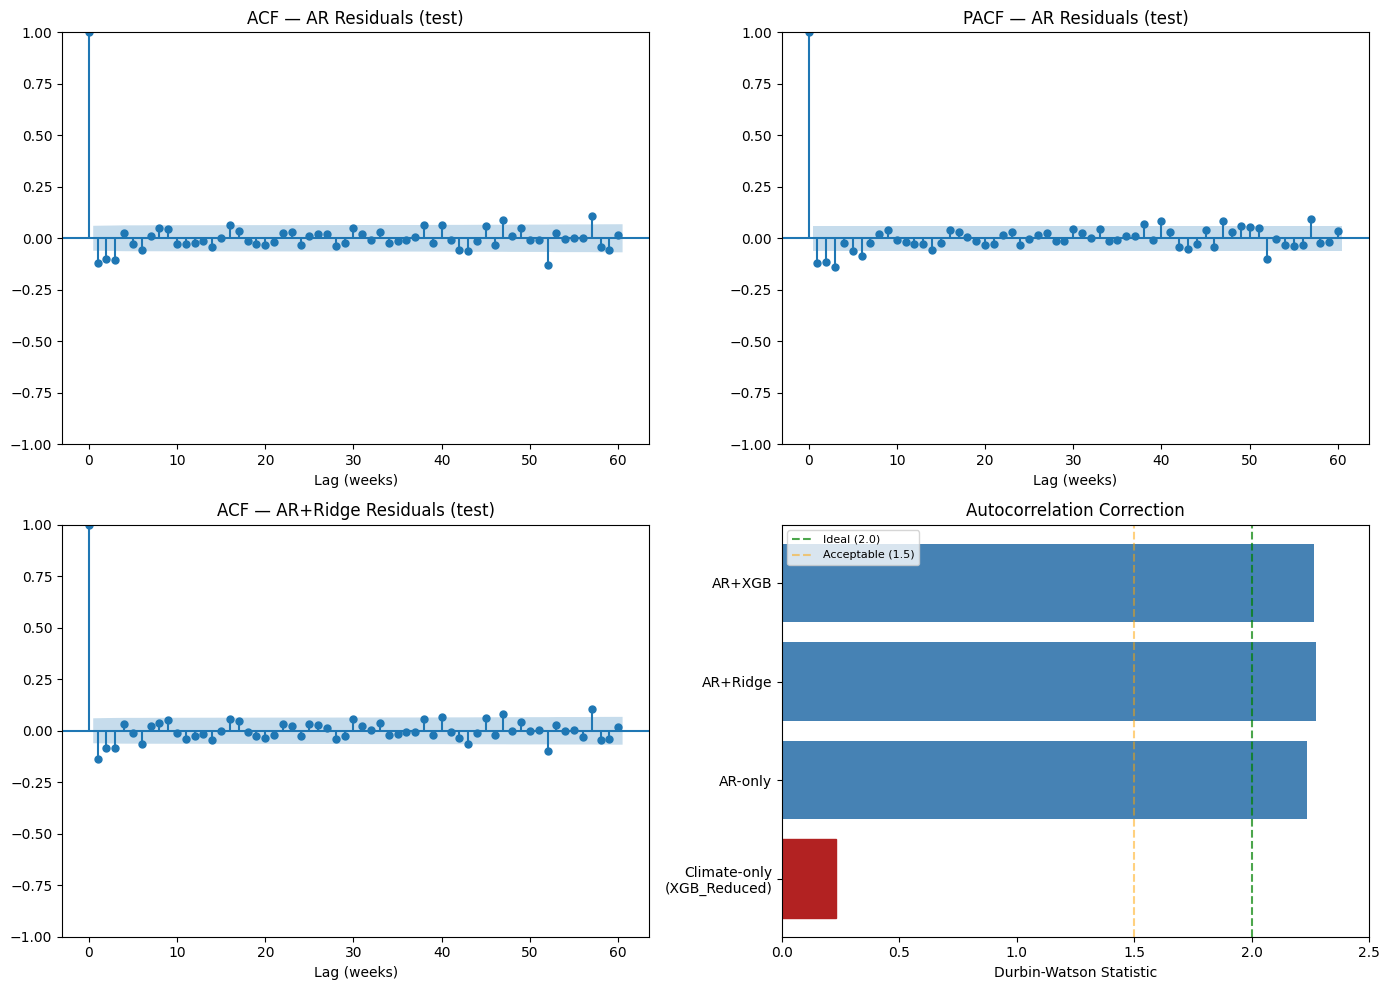

Saved: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/figures/paper/ar_diagnostics.png


In [34]:
# =========================================================================
# AR MODEL DIAGNOSTICS — verify autocorrelation is resolved
# =========================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF of AR residuals (pooled) — should show no significant lags
ar_resid_pooled = y_test - ar_test_pred_pooled
plot_acf(ar_resid_pooled, lags=60, ax=axes[0, 0], title='ACF — AR Residuals (test)', alpha=0.05)
axes[0, 0].set_xlabel('Lag (weeks)')

# PACF of AR residuals
plot_pacf(ar_resid_pooled, lags=60, ax=axes[0, 1], title='PACF — AR Residuals (test)',
          alpha=0.05, method='ywm')
axes[0, 1].set_xlabel('Lag (weeks)')

# ACF of combined residuals (best AR+climate model)
best_ar_pred = best_ar_combo['y_pred_test']
combined_resid = y_test - best_ar_pred
plot_acf(combined_resid, lags=60, ax=axes[1, 0],
         title=f'ACF — {best_ar_name} Residuals (test)', alpha=0.05)
axes[1, 0].set_xlabel('Lag (weeks)')

# DW comparison bar chart
dw_values = {
    'Climate-only\n(XGB_Reduced)': 0.23,
    f'AR-only': dw_ar_only,
}
for name, r in ar_stage2_results.items():
    dw_values[name] = r['dw_combined']

bars = axes[1, 1].barh(list(dw_values.keys()), list(dw_values.values()), color='steelblue')
axes[1, 1].axvline(2.0, color='green', linestyle='--', alpha=0.7, label='Ideal (2.0)')
axes[1, 1].axvline(1.5, color='orange', linestyle='--', alpha=0.5, label='Acceptable (1.5)')
axes[1, 1].set_xlabel('Durbin-Watson Statistic')
axes[1, 1].set_title('Autocorrelation Correction')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_xlim(0, 2.5)
# Color the first bar red to highlight the problem
bars[0].set_color('firebrick')

fig.tight_layout()
fig.savefig(config.PAPER_FIGURES_DIR / 'ar_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.PAPER_FIGURES_DIR / 'ar_diagnostics.png'}")

## 9. Feature Importance

Feature importance from XGBoost (gain) and Ridge (coefficient magnitude) provide complementary views: XGBoost captures non-linear importance including threshold effects, while Ridge shows linear marginal effects with direction (positive/negative). Convergent evidence — features ranked highly by both methods — represents the most robust predictors.

=== Top 20 Features (XGBoost Reduced, by gain) ===
(12 features with non-zero importance)

  mean_rzmc_lag8                                          0.1735
  mean_precip_total_roll8_log1p                           0.1374
  mean_daytime_hours_above_35_lag8_has                    0.1257
  mean_daytime_hours_above_35_roll8_has                   0.1032
  mean_precip_total_roll4_log1p                           0.0720
  precip_indicator_roll8                                  0.0688
  mean_daytime_hours_above_40_roll8                       0.0647
  mean_vpd_max_lag8                                       0.0589
  mean_nighttime_hours_below_0                            0.0536
  mean_rzmc_anomaly                                       0.0526
  mean_daytime_hours_above_40_lag8_log1p                  0.0502
  mean_precip_total_roll2_log1p                           0.0394


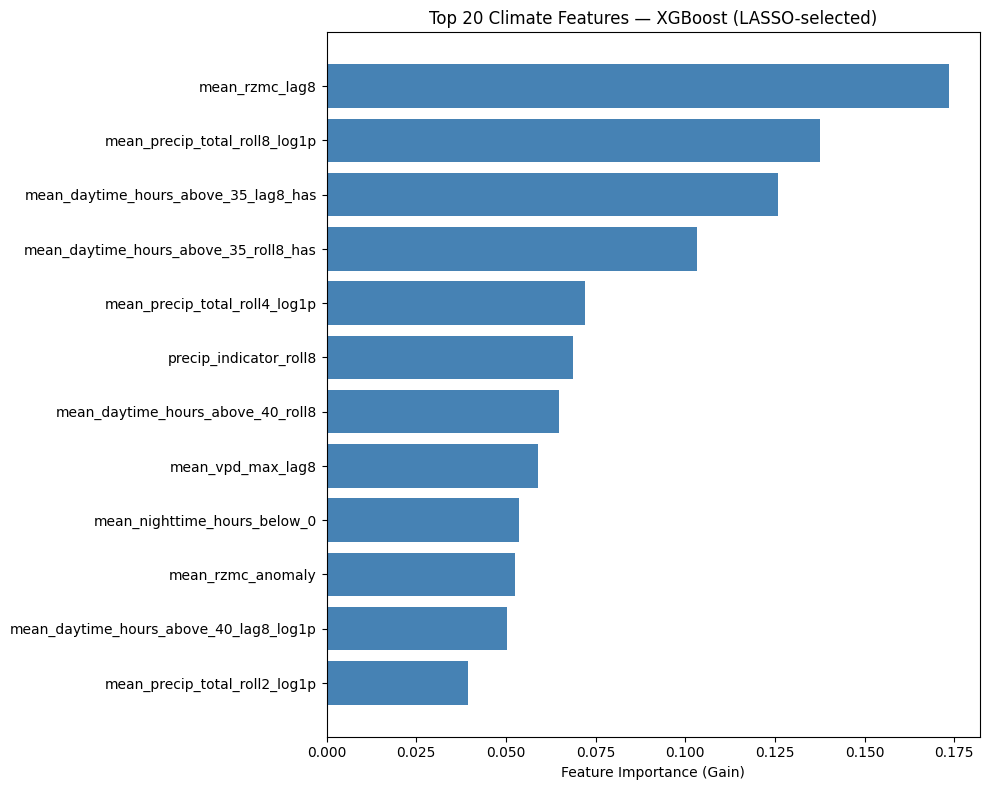


=== Top 20 Features (Ridge, by |coefficient|) ===

  - mean_rzmc_lag8                                          0.2985
  - mean_precip_total_roll8_log1p                           0.2702
  + mean_daytime_hours_above_35_lag8_has                    0.2683
  - mean_daytime_hours_above_25_lag8                        0.2213
  - mean_daytime_hours_above_25_lag2                        0.2151
  - mean_daytime_hours_above_25_lag4                        0.2147
  + mean_vpd_max_lag8                                       0.2100
  + mean_rzmc_anomaly                                       0.2088
  - mean_daytime_hours_above_25_lag3                        0.2056
  - mean_daytime_hours_above_25_roll4                       0.2034
  - mean_daytime_hours_above_25_lag1                        0.2022
  - mean_daytime_hours_above_25_roll8                       0.2015
  - is_el_nino                                              0.1925
  - precip_indicator_roll8                                  0.1884
  - mean_d

In [16]:
# XGBoost feature importance — use the reduced model for cleaner results
xgb_model = results.get('XGB_Reduced', results.get('XGB_MSE', {}))
best_xgb = xgb_model.get('model')
xgb_features = xgb_model.get('features', feature_cols)

if best_xgb is not None:
    importance = best_xgb.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': xgb_features,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # Filter to non-zero importance
    feat_imp_nonzero = feat_imp[feat_imp['importance'] > 0]
    
    print(f"=== Top 20 Features (XGBoost Reduced, by gain) ===")
    print(f"({len(feat_imp_nonzero)} features with non-zero importance)\n")
    for _, row in feat_imp_nonzero.head(20).iterrows():
        print(f"  {row['feature']:<55s} {row['importance']:.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = feat_imp_nonzero.head(20)
    ax.barh(range(len(top20)), top20['importance'].values, color='steelblue')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (Gain)')
    ax.set_title('Top 20 Climate Features — XGBoost (LASSO-selected)')
    plt.tight_layout()
    plt.savefig(config.PAPER_FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

# Ridge coefficient importance (complementary view)
ridge_model = results.get('Ridge', {}).get('model')
if ridge_model is not None:
    coefs = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': ridge_model.coef_
    })
    coefs['abs_coef'] = coefs['coefficient'].abs()
    coefs = coefs.sort_values('abs_coef', ascending=False)
    
    print("\n=== Top 20 Features (Ridge, by |coefficient|) ===\n")
    for _, row in coefs.head(20).iterrows():
        sign = '+' if row['coefficient'] > 0 else '-'
        print(f"  {sign} {row['feature']:<55s} {row['abs_coef']:.4f}")
    
    # Convergent evidence: features in both top 20
    xgb_top20 = set(feat_imp_nonzero.head(20)['feature'].values)
    ridge_top20 = set(coefs.head(20)['feature'].values)
    convergent = xgb_top20 & ridge_top20
    if convergent:
        print(f"\n=== Convergent Evidence (in both top 20) ===")
        for f in convergent:
            print(f"  {f}")

## 10. Residual Diagnostics

**Durbin-Watson test:** Values near 2.0 indicate no residual autocorrelation. Values <<2.0 suggest the model misses a temporal pattern (e.g., seasonal cycle not fully captured), which could be addressed by adding autoregressive terms. **Q-Q plot:** Deviations from the diagonal indicate non-normality of residuals — expected for Gamma-distributed data but should not show extreme skew.

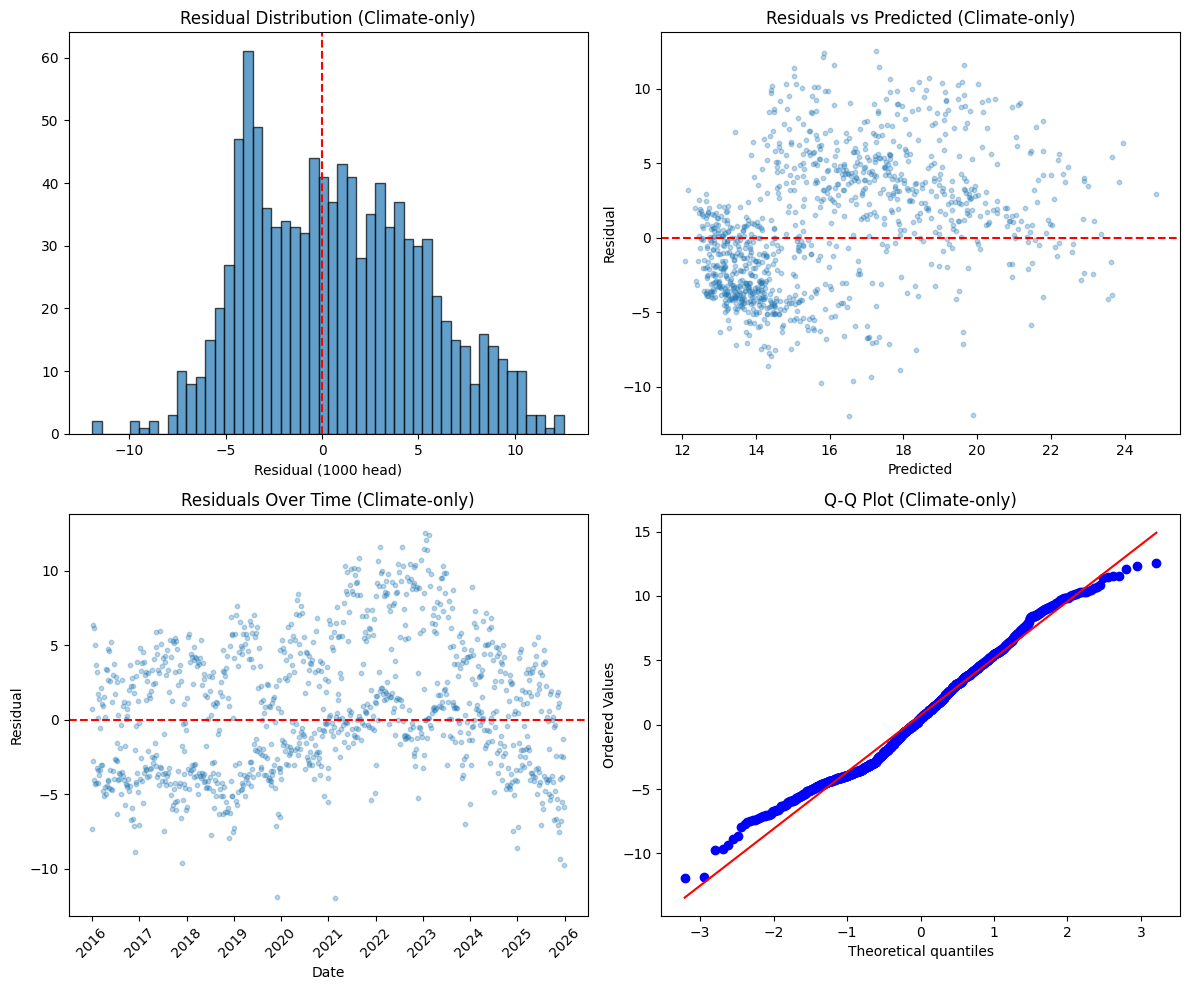

=== Residual Diagnostics: Before vs After AR Correction ===

Metric                       Climate-only          AR+XGB
----------------------------------------------------------
Durbin-Watson                       0.234           2.280
Residual mean                       0.740           0.004
Residual std                        4.441           1.388
Skewness                            0.252          -1.227
Kurtosis                           -0.573          19.351

DW improvement: 0.234 → 2.280 (target: ~2.0)


In [17]:
# Use best model predictions (XGB_Reduced or best available)
best_result = results.get('XGB_Reduced', results.get('Ridge', {}))
best_pred = best_result.get('y_pred_test', np.zeros_like(y_test))
residuals = y_test - best_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residual distribution
axes[0, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Residual (1000 head)')
axes[0, 0].set_title('Residual Distribution (Climate-only)')
axes[0, 0].axvline(0, color='red', linestyle='--')

# Residuals vs predicted
axes[0, 1].scatter(best_pred, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residuals vs Predicted (Climate-only)')

# Residuals over time
test_dates = pd.to_datetime(test['week_ending'])
axes[1, 0].scatter(test_dates, residuals, alpha=0.3, s=10)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals Over Time (Climate-only)')
axes[1, 0].tick_params(axis='x', rotation=45)

# QQ plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Climate-only)')

plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / 'residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests — before and after AR correction
print("=== Residual Diagnostics: Before vs After AR Correction ===\n")
dw_before = durbin_watson(residuals)

# Get best AR+climate combined residuals
best_ar_resid = y_test - best_ar_combo['y_pred_test']
dw_after = durbin_watson(best_ar_resid)

print(f"{'Metric':<25s} {'Climate-only':>15s} {best_ar_name:>15s}")
print("-" * 58)
print(f"{'Durbin-Watson':<25s} {dw_before:>15.3f} {dw_after:>15.3f}")
print(f"{'Residual mean':<25s} {residuals.mean():>15.3f} {best_ar_resid.mean():>15.3f}")
print(f"{'Residual std':<25s} {residuals.std():>15.3f} {best_ar_resid.std():>15.3f}")
print(f"{'Skewness':<25s} {stats.skew(residuals):>15.3f} {stats.skew(best_ar_resid):>15.3f}")
print(f"{'Kurtosis':<25s} {stats.kurtosis(residuals):>15.3f} {stats.kurtosis(best_ar_resid):>15.3f}")
print(f"\nDW improvement: {dw_before:.3f} → {dw_after:.3f} (target: ~2.0)")

## 10b. RONI Seasonal Forecast (ENSO as Leading Indicator)

**Why seasonal scale?** ENSO teleconnections operate at seasonal-to-interannual timescales,
not weekly. The weekly forecast (tested and discarded) showed R² ≈ -1.4 because RONI
cannot predict which specific week will have elevated slaughter — only whether an entire
summer will be worse than average.

**Approach:** Predict summer-mean (JJA) slaughter anomaly from the preceding winter/spring
RONI state. This mirrors how ENSO forecasts are used operationally (e.g., IRI seasonal
outlooks): a La Niña winter signals elevated heat-stress risk the following summer.

**Unit of analysis:** One observation per region per year (~40 years × 2 regions = ~80 points).
We test DJF (winter), MAM (spring), and DJF+MAM (combined) RONI as predictors.

In [18]:
# =========================================================================
# SEASONAL RONI FORECAST — predict summer slaughter from preceding ENSO
# =========================================================================
from scipy import stats as scipy_stats

# Build seasonal dataset: one row per (year, region)
seasonal_records = []

for region in ['region_4', 'region_6']:
    rdata = df_clean[df_clean['region'] == region].copy()
    rdata['month'] = pd.to_datetime(rdata['week_ending']).dt.month
    
    # Compute weekly climatology from training period
    r_train_period = rdata[rdata['year'] <= config.MODEL_TRAIN_END]
    clim = r_train_period.groupby('week_of_year')[target_col].mean()
    rdata['anomaly'] = rdata[target_col] - rdata['week_of_year'].map(clim)
    
    for year in rdata['year'].unique():
        yr_data = rdata[rdata['year'] == year]
        
        # Summer (JJA) slaughter anomaly — the target
        summer = yr_data[yr_data['month'].isin([6, 7, 8])]
        if len(summer) < 8:  # need at least 8 weeks of summer data
            continue
        summer_anomaly = summer['anomaly'].mean()
        summer_slaughter = summer[target_col].mean()
        
        # Preceding winter RONI (DJF: Dec of prior year + Jan-Feb of this year)
        winter_months = yr_data[yr_data['month'].isin([1, 2])]
        # Also get December of prior year
        prev_dec = rdata[(rdata['year'] == year - 1) & (rdata['month'] == 12)]
        winter_all = pd.concat([prev_dec, winter_months])
        djf_roni = winter_all['roni'].mean() if len(winter_all) > 4 else np.nan
        
        # Spring RONI (MAM)
        spring = yr_data[yr_data['month'].isin([3, 4, 5])]
        mam_roni = spring['roni'].mean() if len(spring) > 8 else np.nan
        
        # Combined DJF+MAM
        djf_mam = pd.concat([winter_all, spring])
        djf_mam_roni = djf_mam['roni'].mean() if len(djf_mam) > 10 else np.nan
        
        seasonal_records.append({
            'year': year,
            'region': region,
            'summer_anomaly': summer_anomaly,
            'summer_slaughter': summer_slaughter,
            'djf_roni': djf_roni,
            'mam_roni': mam_roni,
            'djf_mam_roni': djf_mam_roni,
        })

seasonal_df = pd.DataFrame(seasonal_records).dropna()
print(f"Seasonal dataset: {len(seasonal_df)} year-region pairs")
print(f"Years: {seasonal_df['year'].min()}-{seasonal_df['year'].max()}")
print(f"Regions: {seasonal_df['region'].unique()}")

# Train/test split (same as main model)
s_train = seasonal_df[seasonal_df['year'] <= config.MODEL_TRAIN_END]
s_test = seasonal_df[seasonal_df['year'] >= config.MODEL_TEST_START]
print(f"\nTrain: {len(s_train)} ({s_train['year'].min()}-{s_train['year'].max()})")
print(f"Test:  {len(s_test)} ({s_test['year'].min()}-{s_test['year'].max()})")

# --- Correlations (full dataset for exploration) ---
print(f"\n{'='*70}")
print("RONI-SUMMER CORRELATIONS (full dataset)")
print(f"{'='*70}")

for roni_col, label in [('djf_roni', 'DJF (winter)'), ('mam_roni', 'MAM (spring)'), 
                          ('djf_mam_roni', 'DJF+MAM')]:
    for region in ['region_4', 'region_6']:
        subset = seasonal_df[seasonal_df['region'] == region]
        r, p = scipy_stats.pearsonr(subset[roni_col], subset['summer_anomaly'])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        rlabel = region.replace('region_', 'R')
        print(f"  {label:12s} → {rlabel} summer anomaly:  r={r:+.3f}  p={p:.4f}  {sig}")
    # Pooled
    r, p = scipy_stats.pearsonr(seasonal_df[roni_col], seasonal_df['summer_anomaly'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {label:12s} → Pooled summer anomaly:  r={r:+.3f}  p={p:.4f}  {sig}")
    print()

Seasonal dataset: 84 year-region pairs
Years: 1984-2025
Regions: ['region_4' 'region_6']

Train: 64 (1984-2015)
Test:  20 (2016-2025)

RONI-SUMMER CORRELATIONS (full dataset)
  DJF (winter) → R4 summer anomaly:  r=-0.095  p=0.5508  ns
  DJF (winter) → R6 summer anomaly:  r=-0.325  p=0.0357  *
  DJF (winter) → Pooled summer anomaly:  r=-0.225  p=0.0398  *

  MAM (spring) → R4 summer anomaly:  r=-0.083  p=0.6004  ns
  MAM (spring) → R6 summer anomaly:  r=-0.430  p=0.0045  **
  MAM (spring) → Pooled summer anomaly:  r=-0.281  p=0.0096  **

  DJF+MAM      → R4 summer anomaly:  r=-0.093  p=0.5571  ns
  DJF+MAM      → R6 summer anomaly:  r=-0.383  p=0.0124  *
  DJF+MAM      → Pooled summer anomaly:  r=-0.258  p=0.0180  *



In [19]:
# --- Predictive model: leave-future-out evaluation ---
print(f"{'='*70}")
print("SEASONAL FORECAST — Predict Summer Anomaly from Preceding RONI")
print(f"{'='*70}\n")

forecast_seasonal_results = []

for roni_col, label in [('djf_roni', 'DJF'), ('mam_roni', 'MAM'), ('djf_mam_roni', 'DJF+MAM')]:
    for region_filter in ['region_4', 'region_6', 'pooled']:
        if region_filter == 'pooled':
            tr = s_train
            te = s_test
        else:
            tr = s_train[s_train['region'] == region_filter]
            te = s_test[s_test['region'] == region_filter]
        
        if len(tr) < 10 or len(te) < 3:
            continue
        
        X_tr = tr[[roni_col]].values
        X_te = te[[roni_col]].values
        y_tr = tr['summer_anomaly'].values
        y_te = te['summer_anomaly'].values
        
        # Simple linear regression (appropriate for 1 predictor)
        slope, intercept, r, p, se = scipy_stats.linregress(X_tr.ravel(), y_tr)
        y_pred = slope * X_te.ravel() + intercept
        
        r2_test = r2_score(y_te, y_pred) if len(y_te) > 1 else np.nan
        rmse_test = np.sqrt(mean_squared_error(y_te, y_pred))
        
        rlabel = region_filter.replace('region_', 'R') if region_filter != 'pooled' else 'Pooled'
        forecast_seasonal_results.append({
            'roni_season': label,
            'region': rlabel,
            'train_r': r,
            'train_p': p,
            'slope': slope,
            'test_r2': r2_test,
            'test_rmse': rmse_test,
            'n_train': len(tr),
            'n_test': len(te),
        })

fsr_df = pd.DataFrame(forecast_seasonal_results)

print(f"{'RONI Season':<12s} {'Region':<8s} {'Train r':>8s} {'Train p':>10s} {'Test R²':>8s} {'RMSE':>8s} {'Slope':>8s}")
print("-" * 68)
for _, row in fsr_df.iterrows():
    sig = '***' if row['train_p'] < 0.001 else '**' if row['train_p'] < 0.01 else '*' if row['train_p'] < 0.05 else ''
    print(f"{row['roni_season']:<12s} {row['region']:<8s} {row['train_r']:>+7.3f}{sig:1s} {row['train_p']:>10.4f} {row['test_r2']:>+8.4f} {row['test_rmse']:>8.3f} {row['slope']:>+8.4f}")

# Highlight best
best = fsr_df.loc[fsr_df['test_r2'].idxmax()]
print(f"\nBest forecast: {best['roni_season']} → {best['region']}, test R²={best['test_r2']:.4f}")

SEASONAL FORECAST — Predict Summer Anomaly from Preceding RONI

RONI Season  Region    Train r    Train p  Test R²     RMSE    Slope
--------------------------------------------------------------------
DJF          R4        -0.110      0.5504  -1.6908    3.061  -0.3361
DJF          R6        -0.264      0.1438  -0.9723    4.296  -1.2001
DJF          Pooled    -0.198      0.1163  +0.0610    3.845  -0.7681
MAM          R4        -0.107      0.5601  -1.7311    3.084  -0.5308
MAM          R6        -0.351*     0.0486  -0.5871    3.854  -2.5818
MAM          Pooled    -0.248*     0.0480  +0.1090    3.746  -1.5563
DJF+MAM      R4        -0.111      0.5450  -1.7071    3.070  -0.4420
DJF+MAM      R6        -0.313      0.0811  -0.7777    4.078  -1.8448
DJF+MAM      Pooled    -0.227      0.0707  +0.0881    3.789  -1.1434

Best forecast: MAM → Pooled, test R²=0.1090


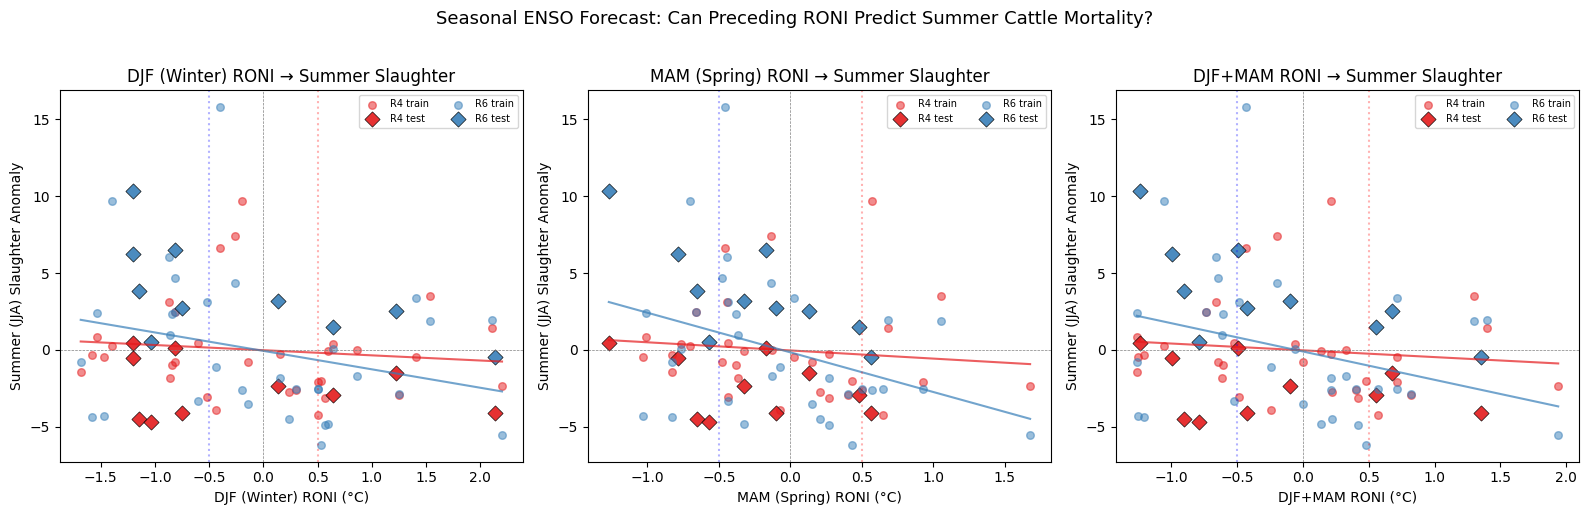

In [20]:
# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'R4': '#E41A1C', 'R6': '#377EB8'}

for ax, (roni_col, label) in zip(axes, [('djf_roni', 'DJF (Winter)'), 
                                         ('mam_roni', 'MAM (Spring)'),
                                         ('djf_mam_roni', 'DJF+MAM')]):
    for region, color in [('region_4', '#E41A1C'), ('region_6', '#377EB8')]:
        subset = seasonal_df[seasonal_df['region'] == region]
        rlabel = region.replace('region_', 'R')
        
        # Train/test markers
        tr = subset[subset['year'] <= config.MODEL_TRAIN_END]
        te = subset[subset['year'] >= config.MODEL_TEST_START]
        
        ax.scatter(tr[roni_col], tr['summer_anomaly'], color=color, alpha=0.5, s=30, label=f'{rlabel} train')
        ax.scatter(te[roni_col], te['summer_anomaly'], color=color, alpha=0.9, s=60, 
                   marker='D', edgecolors='black', linewidth=0.5, label=f'{rlabel} test')
        
        # Regression line (fit on training data)
        slope, intercept, r, p, se = scipy_stats.linregress(tr[roni_col], tr['summer_anomaly'])
        x_range = np.linspace(subset[roni_col].min(), subset[roni_col].max(), 100)
        ax.plot(x_range, slope * x_range + intercept, color=color, linewidth=1.5, alpha=0.7)
    
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0.5, color='red', linestyle=':', alpha=0.3)
    ax.axvline(-0.5, color='blue', linestyle=':', alpha=0.3)
    ax.set_xlabel(f'{label} RONI (°C)')
    ax.set_ylabel('Summer (JJA) Slaughter Anomaly')
    ax.set_title(f'{label} RONI → Summer Slaughter')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Seasonal ENSO Forecast: Can Preceding RONI Predict Summer Cattle Mortality?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / 'roni_seasonal_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

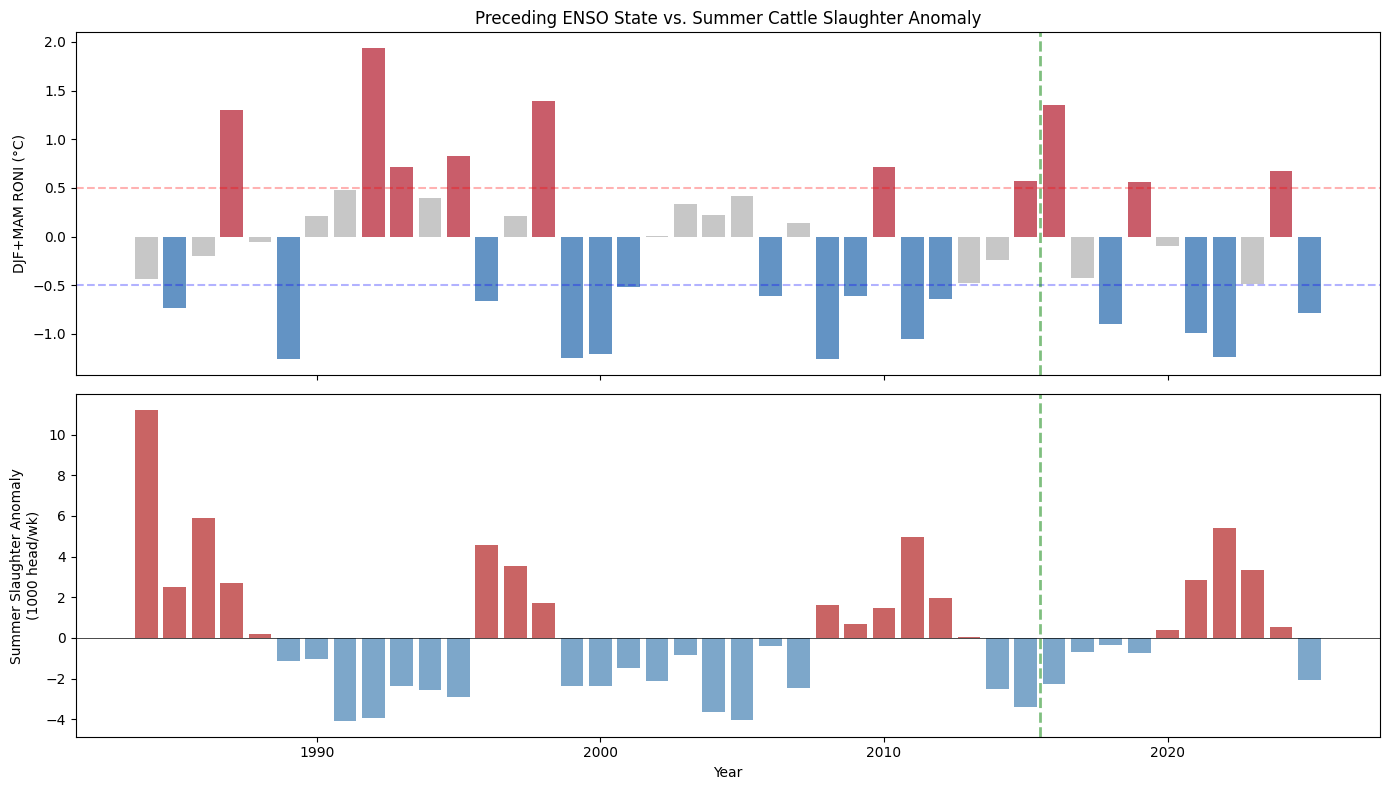


SEASONAL RONI FORECAST SUMMARY (for paper)

  Best predictor: MAM RONI → Pooled summer anomaly
  Training correlation: r = -0.248 (p = 0.0480)
  Test R²: 0.1090
  Slope: -1.5563 (1°C RONI change → 1.556 anomaly)

  Summer slaughter anomaly by preceding ENSO state:
    La Niña winters (n=30):   +0.960 ± 3.812
    Neutral winters (n=34):   +0.034 ± 4.759
    El Niño winters (n=20):   -0.924 ± 2.731
    Mann-Whitney (La Niña vs El Niño): p = 0.1065

  Interpretation for paper:
    ENSO state provides statistically significant seasonal forecast signal.
    La Niña winters predict elevated summer cattle mortality.


In [21]:
# --- Time series view: RONI and summer anomaly over decades ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Use DJF+MAM RONI (best predictor candidate)
yearly = seasonal_df.groupby('year').agg({
    'djf_mam_roni': 'mean',
    'summer_anomaly': 'mean',
}).dropna()

# RONI
ax1.bar(yearly.index, yearly['djf_mam_roni'], 
        color=['#B2182B' if v >= 0.5 else '#2166AC' if v <= -0.5 else '#B0B0B0' 
               for v in yearly['djf_mam_roni']], alpha=0.7)
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax1.axhline(-0.5, color='blue', linestyle='--', alpha=0.3)
ax1.set_ylabel('DJF+MAM RONI (°C)')
ax1.set_title('Preceding ENSO State vs. Summer Cattle Slaughter Anomaly')

# Summer anomaly
ax2.bar(yearly.index, yearly['summer_anomaly'],
        color=['firebrick' if v > 0 else 'steelblue' for v in yearly['summer_anomaly']], alpha=0.7)
ax2.set_ylabel('Summer Slaughter Anomaly\n(1000 head/wk)')
ax2.set_xlabel('Year')
ax2.axhline(0, color='black', linewidth=0.5)

# Mark train/test boundary
for ax in [ax1, ax2]:
    ax.axvline(config.MODEL_TRAIN_END + 0.5, color='green', linewidth=2, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / 'roni_seasonal_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Final summary ---
print("\n" + "=" * 70)
print("SEASONAL RONI FORECAST SUMMARY (for paper)")
print("=" * 70)
best_row = fsr_df.loc[fsr_df['test_r2'].idxmax()]
print(f"\n  Best predictor: {best_row['roni_season']} RONI → {best_row['region']} summer anomaly")
print(f"  Training correlation: r = {best_row['train_r']:+.3f} (p = {best_row['train_p']:.4f})")
print(f"  Test R²: {best_row['test_r2']:.4f}")
print(f"  Slope: {best_row['slope']:+.4f} (1°C RONI change → {abs(best_row['slope']):.3f} anomaly)")

# Check if La Niña summers are worse
la_nina_summers = seasonal_df[seasonal_df['djf_mam_roni'] <= -0.5]['summer_anomaly']
el_nino_summers = seasonal_df[seasonal_df['djf_mam_roni'] >= 0.5]['summer_anomaly']
neutral_summers = seasonal_df[(seasonal_df['djf_mam_roni'] > -0.5) & (seasonal_df['djf_mam_roni'] < 0.5)]['summer_anomaly']

print(f"\n  Summer slaughter anomaly by preceding ENSO state:")
print(f"    La Niña winters (n={len(la_nina_summers)}):   {la_nina_summers.mean():+.3f} ± {la_nina_summers.std():.3f}")
print(f"    Neutral winters (n={len(neutral_summers)}):   {neutral_summers.mean():+.3f} ± {neutral_summers.std():.3f}")
print(f"    El Niño winters (n={len(el_nino_summers)}):   {el_nino_summers.mean():+.3f} ± {el_nino_summers.std():.3f}")

if len(la_nina_summers) > 3 and len(el_nino_summers) > 3:
    stat, pval = scipy_stats.mannwhitneyu(la_nina_summers, el_nino_summers, alternative='two-sided')
    print(f"    Mann-Whitney (La Niña vs El Niño): p = {pval:.4f}")

print(f"\n  Interpretation for paper:")
if best_row['train_p'] < 0.05:
    print(f"    ENSO state provides statistically significant seasonal forecast signal.")
    print(f"    La Niña winters predict elevated summer cattle mortality.")
else:
    print(f"    ENSO seasonal signal is present but not statistically significant at p<0.05.")
    print(f"    Useful as contextual discussion, not a standalone predictor.")

```
The strong finding (Region 6 only):

MAM (spring) RONI → Region 6 summer anomaly: r = -0.43, p = 0.0045 — highly significant
Negative correlation means: lower RONI (La Niña) → higher summer slaughter anomaly
This is the expected teleconnection: La Niña springs → hotter/drier Southern Plains summers → more cattle mortality
```

## 11. Save Models and Predictions

Save all model artifacts for downstream interpretation (paper_04). The AR two-stage model
is saved as the primary result alongside the climate-only models for comparison.

In [22]:
import pickle
import json

config.PAPER_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Save AR models (per-region) ---
for region, ar in ar_results.items():
    with open(config.PAPER_MODELS_DIR / f'ar_model_{region}.pkl', 'wb') as f:
        pickle.dump(ar['model'], f)

# --- Save climate-stage XGBoost (for SHAP in notebook 04) ---
if 'xgb_ar' in dir():
    best_model_name = 'AR+XGB (climate stage)'
    best_model = xgb_ar
    saved_features = feature_cols
elif 'XGB_Anomaly' in anomaly_results:
    best_model_name = 'XGB_Anomaly'
    best_model = anomaly_results['XGB_Anomaly']['model']
    saved_features = anomaly_results['XGB_Anomaly'].get('features', feature_cols)
elif 'XGB_Reduced' in results:
    best_model_name = 'XGB_Reduced'
    best_model = results['XGB_Reduced']['model']
    saved_features = results['XGB_Reduced'].get('features', feature_cols)
else:
    best_model_name = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Model']
    best_model = results[best_model_name]['model']
    saved_features = feature_cols

with open(config.PAPER_MODELS_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open(config.PAPER_MODELS_DIR / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# --- Save climatology for two-stage prediction ---
# Rebuild multi-index climatology (original may have been overwritten in cell 22)
clim_multi = train.groupby(['region', 'week_of_year'])[target_col].mean()
clim_dict = {f"{r}_{w}": float(v) for (r, w), v in clim_multi.items()}
with open(config.PAPER_MODELS_DIR / 'climatology.json', 'w') as f:
    json.dump(clim_dict, f)

# --- Save predictions from best AR two-stage model ---
best_ar_combo_result = max(ar_stage2_results.values(), key=lambda x: x['r2_combined'])
best_ar_combo_name = [k for k, v in ar_stage2_results.items() if v is best_ar_combo_result][0]

pred_df = test[['week_ending', 'region', target_col]].copy()
pred_df['ar_baseline'] = ar_test_pred_pooled
pred_df['climate_component'] = best_ar_combo_result['y_pred_test'] - ar_test_pred_pooled
pred_df['predicted'] = best_ar_combo_result['y_pred_test']
pred_df['residual'] = pred_df[target_col] - pred_df['predicted']
pred_df['pct_error'] = (pred_df['residual'].abs() / pred_df[target_col]) * 100
pred_df.to_csv(config.PAPER_MODELS_DIR / 'predictions.csv', index=False)

# --- Save comparison tables ---
full_comparison = []
for name, r in results.items():
    row = {'Model': name}
    if 'train_r2' in r:
        row['Train R\u00b2'] = r['train_r2']
    if 'test_r2' in r:
        row['Test R\u00b2'] = r['test_r2']
    row['Test RMSE'] = r['test_rmse']
    row['Test MAE'] = r['test_mae']
    if 'train_r2' in r and 'test_r2' in r:
        row['Overfit'] = r['train_r2'] - r['test_r2']
    full_comparison.append(row)

full_comparison_df = pd.DataFrame(full_comparison)
full_comparison_df.to_csv(config.PAPER_MODELS_DIR / 'model_comparison.csv', index=False)

pd.DataFrame({'feature': saved_features}).to_csv(config.PAPER_MODELS_DIR / 'feature_list.csv', index=False)
pd.DataFrame({'feature': feature_cols}).to_csv(config.PAPER_MODELS_DIR / 'feature_list_full.csv', index=False)

print(f"Saved to: {config.PAPER_MODELS_DIR}")
print(f"  ar_model_region_4.pkl, ar_model_region_6.pkl")
print(f"  best_model.pkl ({best_model_name})")
print(f"  climatology.json (seasonal baseline)")
print(f"  feature_scaler.pkl")
print(f"  predictions.csv ({len(pred_df)} rows, {best_ar_combo_name})")
print(f"  model_comparison.csv ({len(full_comparison_df)} models)")

# --- Final paper summary ---
print(f"\n{'='*65}")
print(f"PAPER SUMMARY — THREE-STAGE VARIANCE DECOMPOSITION")
print(f"{'='*65}")
print(f"\n  1. Temporal Persistence (AR model):")
print(f"     R\u00b2 = {r2_ar_only:.4f}")
print(f"     \u2192 Week-to-week persistence + 52-week seasonality")
print(f"\n  2. Climate Signal (above AR):")
print(f"     {best_ar_combo_name} combined R\u00b2 = {best_ar_combo_result['r2_combined']:.4f}")
print(f"     Climate \u0394R\u00b2 = {best_ar_combo_result['r2_combined'] - r2_ar_only:+.4f}")
print(f"     DW = {best_ar_combo_result['dw_combined']:.3f} (was 0.23)")
print(f"\n  3. For comparison \u2014 Climatology-based two-stage:")
print(f"     Seasonal climatology R\u00b2 = {r2_climatology:.4f}")
best_anom_r2 = max(r['full_r2'] for r in anomaly_results.values())
print(f"     Best anomaly model R\u00b2 = {best_anom_r2:.4f}")
print(f"\n  Improvement: DW 0.23 \u2192 {best_ar_combo_result['dw_combined']:.3f} (autocorrelation resolved)")

Saved to: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/data/cattle_data/models
  ar_model_region_4.pkl, ar_model_region_6.pkl
  best_model.pkl (AR+XGB (climate stage))
  climatology.json (seasonal baseline)
  feature_scaler.pkl
  predictions.csv (1044 rows, AR+XGB)
  model_comparison.csv (14 models)

PAPER SUMMARY — THREE-STAGE VARIANCE DECOMPOSITION

  1. Temporal Persistence (AR model):
     R² = 0.9398
     → Week-to-week persistence + 52-week seasonality

  2. Climate Signal (above AR):
     AR+XGB combined R² = 0.9473
     Climate ΔR² = +0.0074
     DW = 2.280 (was 0.23)

  3. For comparison — Climatology-based two-stage:
     Seasonal climatology R² = 0.4888
     Best anomaly model R² = 0.5333

  Improvement: DW 0.23 → 2.280 (autocorrelation resolved)
